In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp
import scipy as sy
from scipy.integrate import odeint
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import root

## An Interacting Affine model of the dark sector

##### $P_X = w\rho_X-(1+w)\rho_\Lambda$ 
##### $w_x = w-(1+w)\frac{\rho_\Lambda}{\rho_X}$

### Using cosmological constant normalisation

$x =\frac{\rho_X}{\rho_\Lambda}$ , $y=\frac{\rho_m}{\rho_\Lambda}$

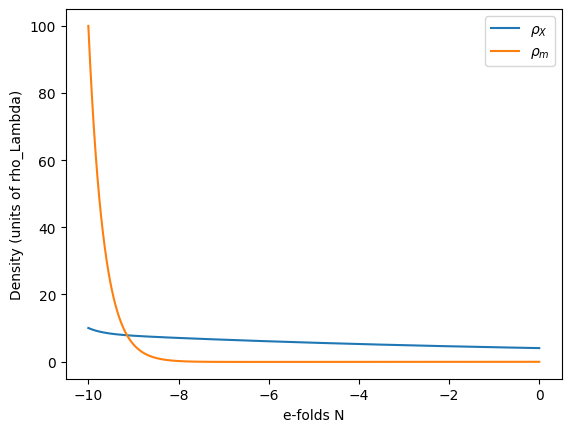

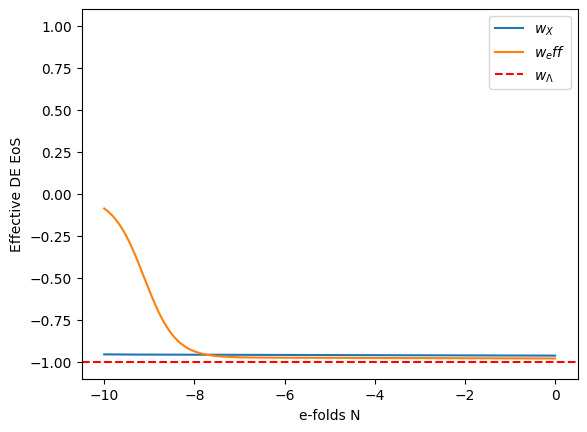

In [2]:
# Parameters to be optimised to lambda cdm data
w = -0.95
q = 0.05


def system(N, vars):
    x, y = vars

    w_x = w - (1 + w)/(x+1e-8)
    
    dx =-3*(1+w)*(x-1) + q*(x-y)
    dy =-3*y - q*(x-y)

    return [dx, dy]

N = np.linspace(-10, 0, 500) # -50 epochs is around the time of inflation but for observational data fitting i need to start today slightly back -10-0 epochs
sol = solve_ivp(system, [-10,0], [10,100] , t_eval=N)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
#large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
x = sol.y[0]
y = sol.y[1]
a = np.exp(sol.t)  # scale factor


rho_X = x * 1  # assuming rho_Lambda = 1 in code units
rho_m = y * 1
rho_tot = rho_X + rho_m + 1
w_x = w - (1 + w)/(x+1e-8)
w_eff = (w*(x-1)-1) /(x+y)

plt.figure()
plt.plot(N, x, label=r'$\rho_X$')
plt.plot(N, y, label=r'$\rho_m$')
plt.xlabel('e-folds N')
plt.ylabel('Density (units of rho_Lambda)')
#plt.xscale('log')  # log scale to show early universe
plt.legend()

plt.figure()
plt.plot(N, w_x, label=r'$w_X$')
plt.plot(N, w_eff, label=r'$w_eff$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.show()

Physical fixed points: [[1.0350877192982457, -0.017543859649122806]]
Fixed points (1.0350877192982457,-0.017543859649122806)
Eigen Values: [-1.44833518 -2.95166482]
Type=node
Stability=Attractor



/tmp/ipykernel_2339/90627675.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


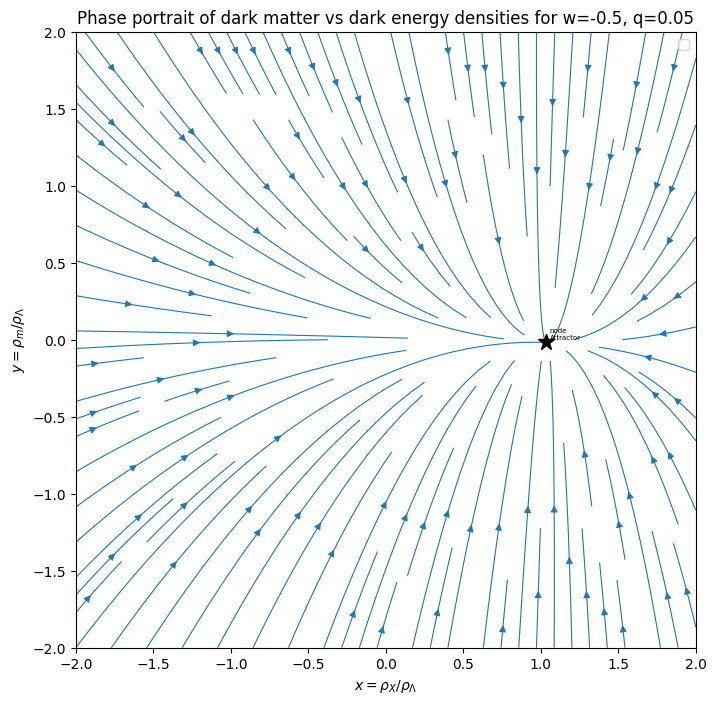

In [3]:
#plotting phase portrait at lambda slice
def phase_plot(w, q):
  def system(t, vars):
      x, y = vars

      #w_x = w - (1 + w)/(x+1e-8)
      
      dx =-3*(1+w)*(x-1) + q*(x-y)
      dy =-3*y - q*(x-y)

      return [dx, dy]

  # plot the dynamics on graph
  initialState=np.array([10, 100])

  simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
  # generate the state-space trajectory

  def stop_event(t, y):
      x, y_ = y
      return abs(x) - 1e-6  # stop near singularity

  stop_event.terminal = True

  sol = solve_ivp(system, [-10,0], initialState , t_eval=simulationTime)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
  #large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
  dx = sol.y[0]
  dy = sol.y[1]
  a = np.exp(sol.t)  # scale factor

  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-2,2,10)
  x1 = np.linspace(-2,2,10)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
              dx,dy= system(0,[X0[i,j], X1[i,j]])
              dX0[i,j] = dx
              dX1[i,j] = dy

# in order to plot trajectories of solutions from fixed points, using sympy to solve the equations dx and dy =0 and 
# finding values of x and y. These can then be used in a jaconian matrix to determine eigenvalues at these fixed points which 
# determines stability.  

  x_FP, y_FP = sp.symbols('x y ', real=True)

  #w_x = w_a - (1 + w_a)/x_FP
  f =-3*(1+w)*(x_FP-1) + q*(x_FP-y_FP)
  g =-3*y_FP - q*(x_FP-y_FP)
  J_sym = sp.Matrix([f, g]).jacobian([x_FP, y_FP]) # Symbolic Jacobian for x and y 2D

  solutions = sp.solve([f, g], [x_FP, y_FP], dict=True)
  FP=[]
  for sol in solutions:
    if x_FP in sol and y_FP in sol:
      x_val = sol[x_FP]
      y_val = sol[y_FP]
      #z_val = sol[z_FP]
      #lam_val = sol[lam_FP]
      if x_val.is_real and y_val.is_real:
          x_val,y_val = float(x_val),float(y_val)
          FP.append([float(x_val),float(y_val)])
  print("Physical fixed points:", FP)

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, density=1.2, linewidth=0.8)
  #plt.plot(x_vals, y_vals, 'r', lw=2, label='Trajectory')
  #plt.plot(x_vals[0], y_vals[0], 'ro', label='Initial condition')


# classifying E vals in accordance with dynamical system analysis
  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

# plotting the fixed points by determining their eigenvalues and then classifying them using the above function
  for fp in FP:
    x_c, y_c = fp
    J_num = np.array(J_sym.subs({x_FP: x_c,y_FP: y_c}),dtype=float)
    eigvals,eigvecs = np.linalg.eig(J_num)
    stability,point_type = classify_FP(eigvals)
    print(f'Fixed points ({x_c:},{y_c})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plt.plot(x_c, y_c, 'k*', markersize=12)
    plt.text(x_c+0.02, y_c+0.02, f"{point_type}\n{stability}", fontsize=5)

# a separatrix is plotted from a saddle point and divides areas of different dynamics along the eigenvector direction


    if stability=='saddle': 
       delta=1e-5 # small perturbations along eigenvector
       for vector,value in zip(eigvecs.T,eigvals):
          if value>0:
             for pm in [-1,1]: #either positive of negative direction
              x_start = np.array([x_c,y_c])+pm*delta*vector[:2]
              trajectory= solve_ivp(fun=system,t_span=(simulationTime[0], simulationTime[-1]),y0=x_start,t_eval=simulationTime,method='RK45',events=stop_event)
              plt.plot(trajectory.y[0],trajectory.y[1],'r--',linewidth=1)
    

  plt.xlabel(r"$x = \rho_X/ \rho_\Lambda$")
  plt.ylabel(r"$y=\rho_m/ \rho_\Lambda$")
  plt.title(rf"Phase portrait of dark matter vs dark energy densities for w={w}, q={q}")
  #plt.xlim(-1.5,1.5)
  #plt.ylim(-1.5,1.5)
  plt.legend()
  plt.show()





# try w=-0.95 and -0.5 and q=+- 0.05
phase_plot(-0.5,0.05)

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018/meta


#### Plot of x vs y vs $w_{eff}$

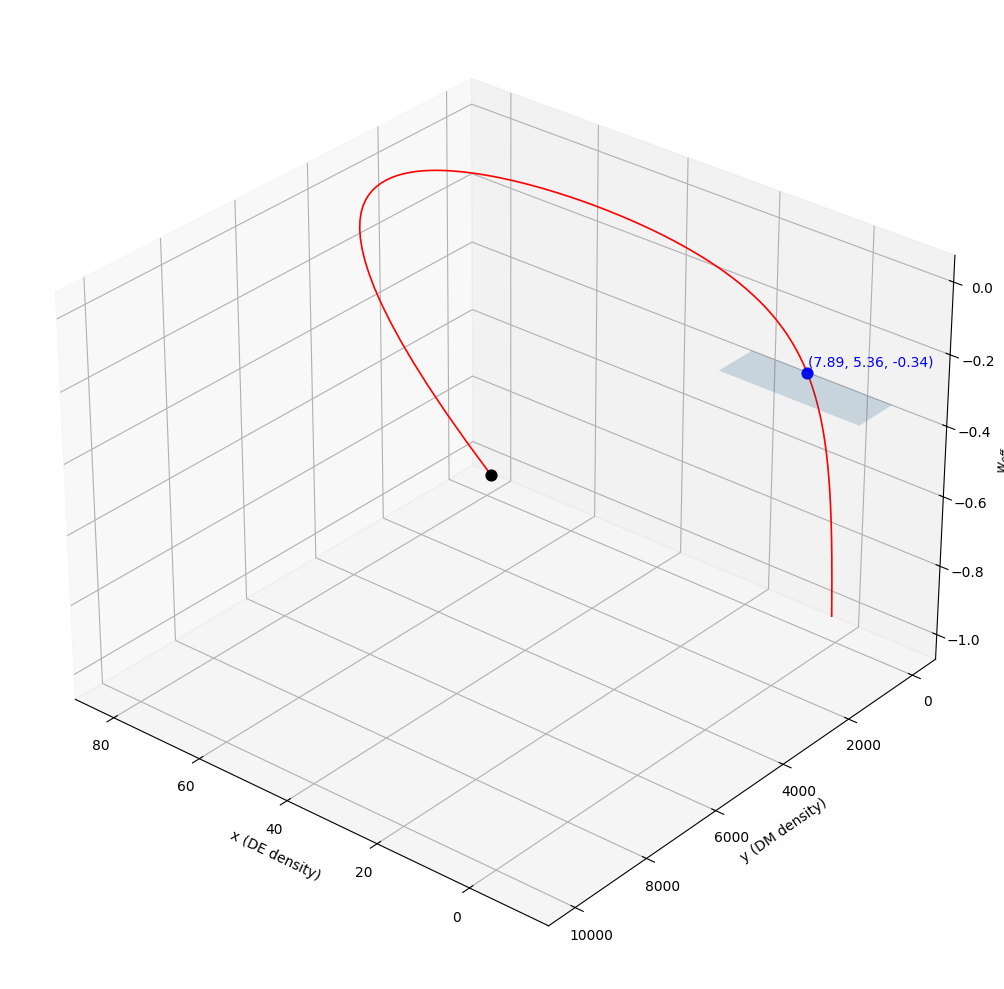

In [4]:
w,q=-0.5,-0.05



def system(t, vars):
      x, y = vars

      #w_x = w - (1 + w)/(x+1e-8)
      
      dx =-3*(1+w)*(x-1) + q*(x-y)
      dy =-3*y - q*(x-y)

      return [dx, dy]

  # plot the dynamics on graph
initialState=np.array([1, 10000]) # x~1   y=y0e^-3N~1e13

simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
  # generate the state-space trajectory

sol = solve_ivp(system, [-10,0], initialState , t_eval=simulationTime)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
  #large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
x = sol.y[0]
y = sol.y[1]
weff=((w*(x-1)-1)/(x+y))

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(x, y, weff, color='r', lw=1.2)
ax.scatter3D(x[0], y[0], weff[0], color='black', s=60)

a = np.linspace(-10, 20, 100)
b = np.linspace(-10, 1000, 10000)
X, Y = np.meshgrid(a, b)
Z = np.ones(X.shape) * -1/3
ax.plot_surface(X, Y, Z, alpha=0.2)

idx = np.where(np.isclose(weff, -1/3, atol=3e-3))[0]
for i in idx:
    ax.scatter3D(x[i], y[i], weff[i], color='blue', s=60)
    ax.text(x[i]+0.02, y[i]+0.02, weff[i]+0.02, f"({x[i]:.2f}, {y[i]:.2f}, {weff[i]:.2f})", color='b')

      

ax.set_xlabel("x (DE density)")
ax.set_ylabel("y (DM density)")
ax.set_zlabel("$w_{eff}$")
ax.view_init(elev=30, azim=130)
plt.tight_layout()
plt.show()

## Using H normalised variables
#### from the affine equation of state we find $\rho_X=\rho_{dyn}+\rho_\Lambda$
#### so the Friedmann equation, $H^2 = 1/3 (\rho_m+\rho_X) =1/3 (\rho_{dyn}+\rho_m +\rho_\Lambda)$, becomes 1=x+y+z where:

#### $x=\frac{\rho_{dyn}}{3H^2}$, $y=\frac{\rho_{m}}{3H^2}$, $z=\frac{\rho_{\Lambda}}{3H^2}$ with ranges $0\leq x,y,z \leq 1 $
#### using these variables, we find that the continuity equations become a 2D system using the Friedmann constaint z=1-x-y and using the interaction term $Q=qH(\rho_X-\rho_m)$

#### $x' = 3(1+w)(x^2-x)+3xy+q(1-2y)$
#### $y' = 3(y^2-y)+3xy(1+w) -q(1-2y)$

#### $w_{eff} = \frac{P_X}{\rho_X+\rho_m}=\frac{w(\rho_X-\rho_\Lambda)-\rho_\Lambda}{\rho_X+\rho_m}$
#### $w_{eff} = \frac{wx-z}{x+y+z}= (1+w)x+y-1$

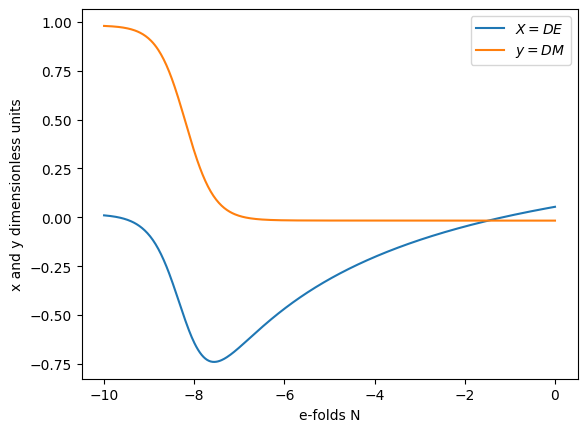

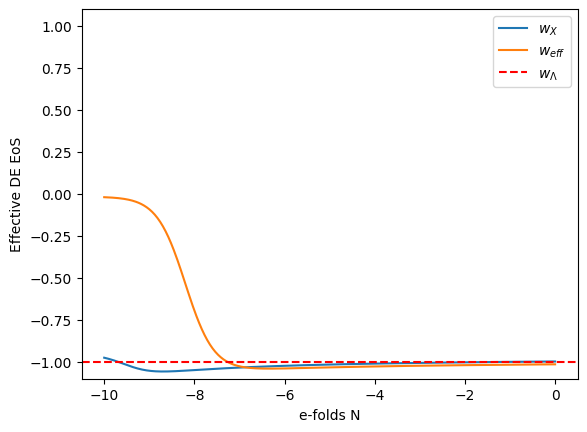

In [5]:
w,q =-0.95,0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]

simulationTime=np.linspace(-10,0,500)
solution = solve_ivp(system,[-10,0],[0.01,0.98],t_eval=simulationTime)
x=solution.y[0]
y=solution.y[1]
wx= ((1+w)*x +y-1)/(1-y+1e-6)
weff=(1+w)*x +y-1



plt.figure()
plt.plot(simulationTime, x, label=r'$X=DE$')
plt.plot(simulationTime, y, label=r'$y=DM$')
plt.xlabel('e-folds N')
plt.ylabel('x and y dimensionless units')
#plt.xscale('log')  # log scale to show early universe
plt.legend()

plt.figure()
plt.plot(simulationTime, wx, label=r'$w_X$')
plt.plot(simulationTime, weff, label=r'$w_{eff}$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.show()

## 2D plot of x and y reduced by condition z=1-x-y

Detected fixed points: [array([ 0.344828, -0.017241]), array([ 1.017852, -0.017852]), array([0.017236, 0.982764])]


Fixed points (0.344828,-0.017241)
Eigen Values: [-0.0991218 -2.9508746]
Type=node
Stability=Attractor

Fixed points (0.017236,0.982764)
Eigen Values: [2.8517548 2.9508774]
Type=node
Stability=Repeller



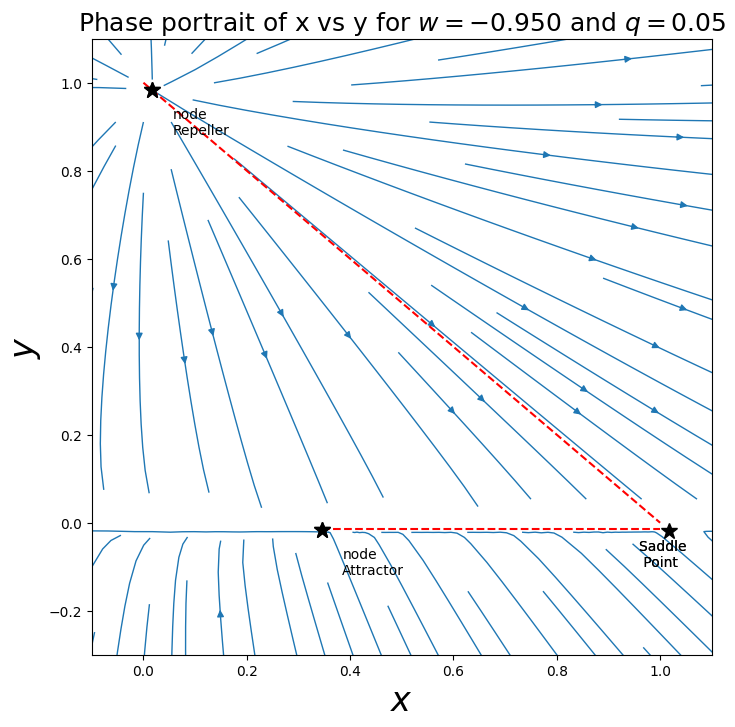

In [6]:
w,q =-0.95,0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]



simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
# generate the state-space trajectory
ICs=[0.00001,0.99]

def traj(IC): # change to forward time -50,50 for expanding and 50,-50 reverse time for contracting
    sol = solve_ivp(system, t_span=(simulationTime[0],simulationTime[-1]), y0=ICs,t_eval=simulationTime, method='RK45', rtol=1e-6, atol=1e-6)
    return sol

def plot_traj(sol):
    x = sol.y[0]
    y = sol.y[1]

    #plt.plot(x,y ,color='r',linestyle='--',alpha = 0.7,label="Trajectory")
    x0,y0 = x[-2],y[-2]
    X_diff=x[-1] -x[-2]
    Y_diff=y[-1] -y[-2]
    plt.arrow(x0, y0, X_diff, Y_diff, head_width=0.03, head_length=0.05, length_includes_head=True, color='r',linestyle='--')


#plotting phase portrait 
def phase_plot():

  FP = find_fixed_points()
  

  
  print("Detected fixed points:",FP)


  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-1.5,1.5,500)
  x1 = np.linspace(-1.5,1.5,500)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
                if abs(X0[i,j]) >= 1.5 or abs(X1[i,j]) >= 1.5:
                  dX0[i,j] = 0
                  dX1[i,j] = 0
                else:
                  dx,dy = system(0,[X0[i,j], X1[i,j]])
                  dX0[i,j] = dx
                  dX1[i,j] = dy

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, density=1.9, linewidth=1)
  #plt.plot(x_vals, y_vals, 'r', lw=2, label='Trajectory')
  #plt.plot(x_vals[0], y_vals[0], 'ro', label='Initial condition')

    #   forcing the separatrices for w=-0.5 and q=-0.05, remove otherwise
    #1.54834,-1.50333
  a=np.linspace(0,1,100)
  b=[(-i)+1  for i in a]

  d=np.linspace(0.344828,1,100)
  c=np.zeros_like(d)
  plt.plot(a,b,'r--')
  plt.plot(d,c-0.015,'r--')




  initial_conditions = [(0.99, 0.01), (0.1, 0.99)]
  for dx0,dy0 in initial_conditions:
        sol = traj([dx0,dy0])
        plot_traj(sol)


  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

  for fp in FP:
    x_c, y_c = fp
    plt.plot(x_c, y_c, 'k*', markersize=12)
    delta = 1e-6
    # DO NOT skip the saddle at (1,0)
    if (abs(x_c) >= 1 or abs(y_c) >= 1) and not np.allclose([x_c, y_c], [1,0], atol=1e-3):
      
      stability = "saddle"
      point_type = "Boundary"

      starts = [
                [x_c-delta,y_c],
                [x_c,y_c-delta],
                [x_c-delta,y_c-delta],
                [x_c-delta,y_c+delta]
            ]

      for start in starts:

                  start = np.clip(start,-0.999,0.999)

                  sol = solve_ivp(system,(-10, 0),start,t_eval=simulationTime)
                  #plt.plot(sol.y[0], sol.y[1], 'r--')

      continue






    
    # creating a numerical jacobian because the sympy function doesnt work when functions blow up to infinities at +-1

    eps=1e-6
    fx1 = system(0,[x_c+eps,y_c])
    fx2 = system(0,[x_c-eps,y_c])

    fy1 = system(0,[x_c,y_c+eps])
    fy2 = system(0,[x_c,y_c-eps])

    J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

    eigvals,eigvecs = np.linalg.eig(J)

    stability,point_type = classify_FP(eigvals)




    print(f'Fixed points ({x_c:},{y_c:})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plt.plot(x_c, y_c, 'k*', markersize=12,label='Fixed Points')
    plt.text(x_c+0.04, y_c-0.1, f"{point_type}\n{stability}", fontsize=10)
    plt.text(1-0.04, 0-0.1, f"Saddle \n Point", fontsize=10)
    
    #plt.plot(1,0,'k*', markersize=12,label='Saddle Point')
    #plt.text(1-0.04, 0-0.1, f"Saddle Point", fontsize=10)

  #plt.plot(1,0,'k*', markersize=12,label='Saddle Point')
  plt.xlabel(rf"$x$",fontsize=24)
  plt.ylabel(rf"$y$",fontsize=24)
  plt.title(rf"Phase portrait of x vs y for $w={w:.3f}$ and $q={q}$",fontsize=18)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.3,1.1)


  #plt.legend()
  
  plt.show()





def find_fixed_points():
    guesses = np.linspace(-1.5,1.5,40)
    FP = []
    for g1 in guesses:
        for g2 in guesses:
            sol = root(lambda v: system(0,[v[0],v[1]]), [g1,g2])
            if sol.success:
                x, y = sol.x

                if abs(x) <= 1.5 and abs(y) <= 1.5:
                    dx,dy = system(0,[x,y])

                    if abs(dx) < 1e-6 and abs(dy) < 1e-6:
                        pt = np.round([x,y],6)

                        if not any(np.allclose(pt,p,atol=1e-4) for p in FP):
                            FP.append(pt)

    return FP


phase_plot()

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018


Detected fixed points: [array([-0.032258,  0.016129]), array([0.967777, 0.032223]), array([-0.034443,  1.034443])]
Fixed points (-0.032258,0.016129)
Eigen Values: [-1.54833508 -3.05166492]
Type=node
Stability=Attractor

Fixed points (0.967777,0.032223)
Eigen Values: [ 1.5483345 -1.503331 ]
Type=node
Stability=saddle

Fixed points (-0.034443,1.034443)
Eigen Values: [1.503329  3.0516645]
Type=node
Stability=Repeller



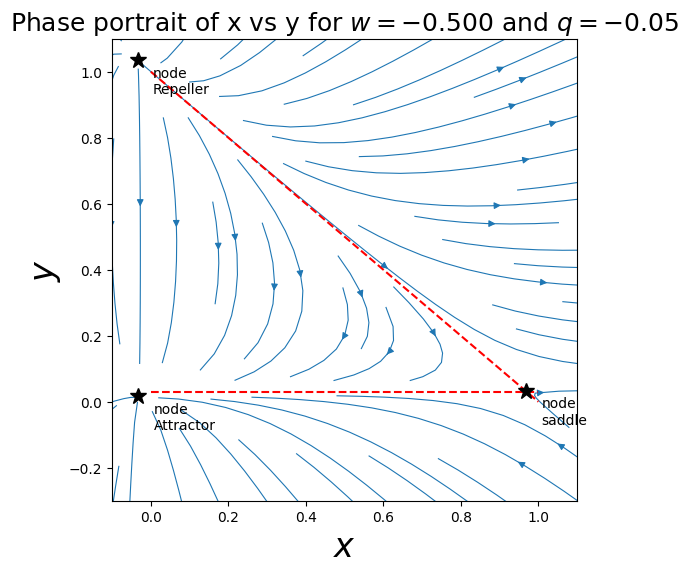

In [7]:
w,q =-0.5,-0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)  # dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)  # dynamic DM
    return [dx,dy]


simulationTime=np.linspace(-10,0,500)
ICs=[0.00001,0.99]

def traj(IC):
    sol = solve_ivp(system, t_span=(simulationTime[0],simulationTime[-1]),
                    y0=ICs, t_eval=simulationTime, method='RK45',
                    rtol=1e-6, atol=1e-6)
    return sol

def plot_traj(sol):
    x = sol.y[0]
    y = sol.y[1]
    plt.plot(x,y ,color='r',linestyle='--',alpha = 0.7)
    x0,y0 = x[-2],y[-2]
    X_diff=x[-1] -x[-2]
    Y_diff=y[-1] -y[-2]
    plt.arrow(x0, y0, X_diff, Y_diff,
              head_width=0.03, head_length=0.05,
              length_includes_head=True, color='r')


def phase_plot():

    FP = find_fixed_points()
    print("Detected fixed points:",FP)

    # vector field grid
    x0 = np.linspace(-1.5,1.5,500)
    x1 = np.linspace(-1.5,1.5,500)
    X0,X1 = np.meshgrid(x0,x1)
    dX0 = np.zeros(X0.shape)
    dX1 = np.zeros(X1.shape)

    for i in range(X0.shape[0]):
        for j in range(X0.shape[1]):
            if abs(X0[i,j]) >= 1.5 or abs(X1[i,j]) >= 1.5:
                dX0[i,j] = 0
                dX1[i,j] = 0
            else:
                dx,dy = system(0,[X0[i,j], X1[i,j]])
                dX0[i,j] = dx
                dX1[i,j] = dy

    plt.figure(figsize=(6,6))
    plt.streamplot(X0, X1, dX0, dX1, density=1.6, linewidth=0.8)

    #   forcing the separatrices for w=-0.5 and q=-0.05, remove otherwise
    #1.54834,-1.50333
    a=np.linspace(0,1,100)
    b=[(-i)+1  for i in a]
    c=np.zeros_like(a)
    plt.plot(a,b,'r--')
    plt.plot(a,c+0.03,'r--')

    initial_conditions = [(0.99, 0.01), (0.1, 0.99)]
    for dx0,dy0 in initial_conditions:
        sol = traj([dx0,dy0])
        #plot_traj(sol)

    # ---------------------------------------------------------
    # Function: plot separatrices ONLY from the saddle (1,0)
    # ---------------------------------------------------------
    def plot_saddle_separatrices(x_c, y_c, J):
        eps = 1e-3

        eigvals, eigvecs = np.linalg.eig(J)

        # unstable eigenvector (positive eigenvalue)
        idx_u = np.argmax(np.real(eigvals))
        v_u = eigvecs[:, idx_u]

        # stable eigenvector (negative eigenvalue)
        idx_s = np.argmin(np.real(eigvals))
        v_s = eigvecs[:, idx_s]

        starts = [
            np.array([x_c, y_c]) + eps * v_u,
            np.array([x_c, y_c]) - eps * v_u,
            np.array([x_c, y_c]) + eps * v_s,
            np.array([x_c, y_c]) - eps * v_s
        ]

        for start in starts:
            # unstable manifold → forward
            sol_f = solve_ivp(system, (0, 10), start,
                              t_eval=np.linspace(0,10,500))
            plt.plot(sol_f.y[0], sol_f.y[1], 'g--', lw=2)

            # stable manifold → backward
            sol_b = solve_ivp(system, (0, -10), start,
                              t_eval=np.linspace(0,-10,500))
            plt.plot(sol_b.y[0], sol_b.y[1], 'b--', lw=2)


    def classify_FP(eigvals,temp=1e-10):
        Real = np.real(eigvals)
        Imag = np.imag(eigvals)
        if np.all(Real<-temp):
            stability = 'Attractor'
        elif np.all(Real>temp):
            stability = 'Repeller'
        elif np.any(Real<-temp) and np.any(Real > temp):
            stability = 'saddle'
        elif np.all(np.abs(Real) < temp):
            stability = 'Centre'
        else:
            stability = 'NaN'
        if np.any(np.abs(Imag)>temp):
            point_type = 'Spiral'
        else:
            point_type = 'node'
        return stability,point_type


    # -------------------------
    # FIXED POINT LOOP
    # -------------------------
    for fp in FP:
        x_c, y_c = fp
        plt.plot(x_c, y_c, 'k*', markersize=12)

        eps=1e-6
        fx1 = system(0,[x_c+eps,y_c])
        fx2 = system(0,[x_c-eps,y_c])
        fy1 = system(0,[x_c,y_c+eps])
        fy2 = system(0,[x_c,y_c-eps])

        J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

        eigvals,eigvecs = np.linalg.eig(J)
        stability,point_type = classify_FP(eigvals)

        print(f'Fixed points ({x_c:},{y_c:})')
        print('Eigen Values:',eigvals)
        print(f'Type={point_type}')
        print(f'Stability={stability}\n')
        plt.text(x_c+0.04, y_c-0.1, f"{point_type}\n{stability}", fontsize=10)

        # ---------------------------------------------------------
        # If this FP is the saddle at (1,0), plot its separatrices
        # ---------------------------------------------------------
        if np.allclose([x_c, y_c], [1.1,-0.1], atol=1e-3):
            plot_saddle_separatrices(x_c, y_c, J)



    plt.xlabel(r"$x$",fontsize=24)
    plt.ylabel(r"$y$",fontsize=24)
    plt.title(rf"Phase portrait of x vs y for $w={w:.3f}$ and $q={q}$",fontsize=18)
    plt.xlim(-0.1,1.1)
    plt.ylim(-0.3,1.1)
    plt.show()



def find_fixed_points():
    guesses = np.linspace(-1.5,1.5,40)
    FP = []
    for g1 in guesses:
        for g2 in guesses:
            sol = root(lambda v: system(0,[v[0],v[1]]), [g1,g2])
            if sol.success:
                x, y = sol.x
                if abs(x) <= 1.5 and abs(y) <= 1.5:
                    dx,dy = system(0,[x,y])
                    if abs(dx) < 1e-6 and abs(dy) < 1e-6:
                        pt = np.round([x,y],6)
                        if not any(np.allclose(pt,p,atol=1e-4) for p in FP):
                            FP.append(pt)
    return FP


phase_plot()


Detected fixed points: [array([ 0.034483, -0.017241]), array([ 1.034443, -0.034443]), array([0.032223, 0.967777])]


Fixed points (0.034483,-0.017241)
Eigen Values: [-1.44833333 -2.95166217]
Type=node
Stability=Attractor

Fixed points (1.034443,-0.034443)
Eigen Values: [ 1.4483355 -1.503329 ]
Type=node
Stability=saddle

Fixed points (0.032223,0.967777)
Eigen Values: [1.503331  2.9516655]
Type=node
Stability=Repeller



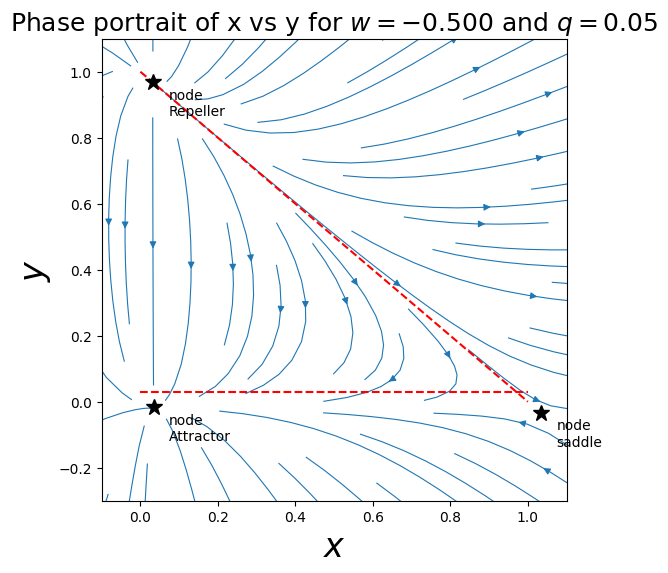

In [8]:
w,q =-0.5,0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)  # dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)  # dynamic DM
    return [dx,dy]


simulationTime=np.linspace(-10,0,500)
ICs=[0.00001,0.99]

def traj(IC):
    sol = solve_ivp(system, t_span=(simulationTime[0],simulationTime[-1]),
                    y0=ICs, t_eval=simulationTime, method='RK45',
                    rtol=1e-6, atol=1e-6)
    return sol

def plot_traj(sol):
    x = sol.y[0]
    y = sol.y[1]
    plt.plot(x,y ,color='r',linestyle='--',alpha = 0.7)
    x0,y0 = x[-2],y[-2]
    X_diff=x[-1] -x[-2]
    Y_diff=y[-1] -y[-2]
    plt.arrow(x0, y0, X_diff, Y_diff,
              head_width=0.03, head_length=0.05,
              length_includes_head=True, color='r')


def phase_plot():

    FP = find_fixed_points()
    print("Detected fixed points:",FP)

    # vector field grid
    x0 = np.linspace(-1.5,1.5,500)
    x1 = np.linspace(-1.5,1.5,500)
    X0,X1 = np.meshgrid(x0,x1)
    dX0 = np.zeros(X0.shape)
    dX1 = np.zeros(X1.shape)

    for i in range(X0.shape[0]):
        for j in range(X0.shape[1]):
            if abs(X0[i,j]) >= 1.5 or abs(X1[i,j]) >= 1.5:
                dX0[i,j] = 0
                dX1[i,j] = 0
            else:
                dx,dy = system(0,[X0[i,j], X1[i,j]])
                dX0[i,j] = dx
                dX1[i,j] = dy

    plt.figure(figsize=(6,6))
    plt.streamplot(X0, X1, dX0, dX1, density=1.6, linewidth=0.8)

    #   forcing the separatrices for w=-0.5 and q=-0.05, remove otherwise
    #1.54834,-1.50333
    a=np.linspace(0,1,100)
    b=[(-i)+1  for i in a]
    c=np.zeros_like(a)
    plt.plot(a,b,'r--')
    plt.plot(a,c+0.03,'r--')

    initial_conditions = [(0.99, 0.01), (0.1, 0.99)]
    for dx0,dy0 in initial_conditions:
        sol = traj([dx0,dy0])
        #plot_traj(sol)

    # ---------------------------------------------------------
    # Function: plot separatrices ONLY from the saddle (1,0)
    # ---------------------------------------------------------
    def plot_saddle_separatrices(x_c, y_c, J):
        eps = 1e-3

        eigvals, eigvecs = np.linalg.eig(J)

        # unstable eigenvector (positive eigenvalue)
        idx_u = np.argmax(np.real(eigvals))
        v_u = eigvecs[:, idx_u]

        # stable eigenvector (negative eigenvalue)
        idx_s = np.argmin(np.real(eigvals))
        v_s = eigvecs[:, idx_s]

        starts = [
            np.array([x_c, y_c]) + eps * v_u,
            np.array([x_c, y_c]) - eps * v_u,
            np.array([x_c, y_c]) + eps * v_s,
            np.array([x_c, y_c]) - eps * v_s
        ]

        for start in starts:
            # unstable manifold → forward
            sol_f = solve_ivp(system, (0, 10), start,
                              t_eval=np.linspace(0,10,500))
            plt.plot(sol_f.y[0], sol_f.y[1], 'g--', lw=2)

            # stable manifold → backward
            sol_b = solve_ivp(system, (0, -10), start,
                              t_eval=np.linspace(0,-10,500))
            plt.plot(sol_b.y[0], sol_b.y[1], 'b--', lw=2)


    def classify_FP(eigvals,temp=1e-10):
        Real = np.real(eigvals)
        Imag = np.imag(eigvals)
        if np.all(Real<-temp):
            stability = 'Attractor'
        elif np.all(Real>temp):
            stability = 'Repeller'
        elif np.any(Real<-temp) and np.any(Real > temp):
            stability = 'saddle'
        elif np.all(np.abs(Real) < temp):
            stability = 'Centre'
        else:
            stability = 'NaN'
        if np.any(np.abs(Imag)>temp):
            point_type = 'Spiral'
        else:
            point_type = 'node'
        return stability,point_type


    # -------------------------
    # FIXED POINT LOOP
    # -------------------------
    for fp in FP:
        x_c, y_c = fp
        plt.plot(x_c, y_c, 'k*', markersize=12)

        eps=1e-6
        fx1 = system(0,[x_c+eps,y_c])
        fx2 = system(0,[x_c-eps,y_c])
        fy1 = system(0,[x_c,y_c+eps])
        fy2 = system(0,[x_c,y_c-eps])

        J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

        eigvals,eigvecs = np.linalg.eig(J)
        stability,point_type = classify_FP(eigvals)

        print(f'Fixed points ({x_c:},{y_c:})')
        print('Eigen Values:',eigvals)
        print(f'Type={point_type}')
        print(f'Stability={stability}\n')
        plt.text(x_c+0.04, y_c-0.1, f"{point_type}\n{stability}", fontsize=10)

        # ---------------------------------------------------------
        # If this FP is the saddle at (1,0), plot its separatrices
        # ---------------------------------------------------------
        if np.allclose([x_c, y_c], [1.1,-0.1], atol=1e-3):
            plot_saddle_separatrices(x_c, y_c, J)



    plt.xlabel(r"$x$",fontsize=24)
    plt.ylabel(r"$y$",fontsize=24)
    plt.title(rf"Phase portrait of x vs y for $w={w:.3f}$ and $q={q}$",fontsize=18)
    plt.xlim(-0.1,1.1)
    plt.ylim(-0.3,1.1)
    plt.show()



def find_fixed_points():
    guesses = np.linspace(-1.5,1.5,40)
    FP = []
    for g1 in guesses:
        for g2 in guesses:
            sol = root(lambda v: system(0,[v[0],v[1]]), [g1,g2])
            if sol.success:
                x, y = sol.x
                if abs(x) <= 1.5 and abs(y) <= 1.5:
                    dx,dy = system(0,[x,y])
                    if abs(dx) < 1e-6 and abs(dy) < 1e-6:
                        pt = np.round([x,y],6)
                        if not any(np.allclose(pt,p,atol=1e-4) for p in FP):
                            FP.append(pt)
    return FP


phase_plot()


### Includes radiation factor so that 1=x+y+z+R

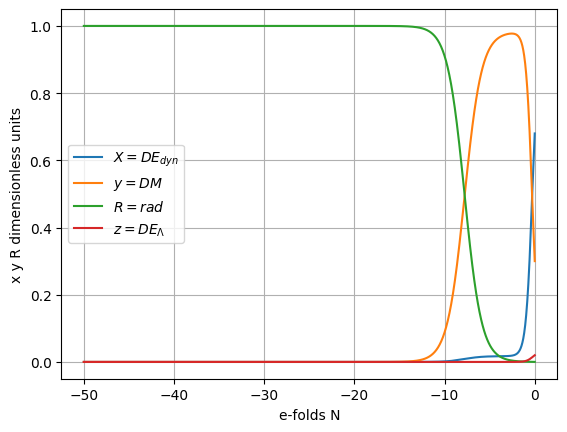

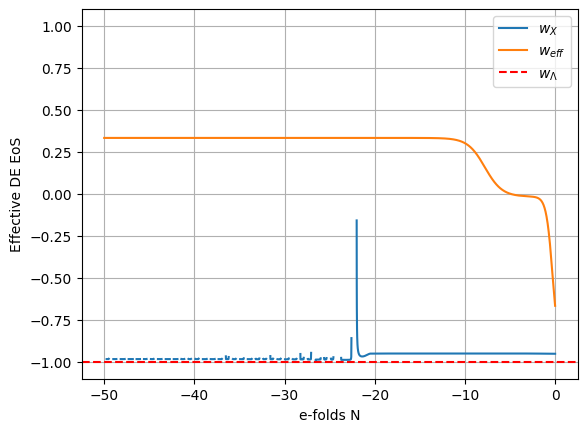

In [9]:
w,q =-0.95,0.05


def system(t,vars):
    x,y,R=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y-R)+4*x*R #dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y-R)+4*y*R #dynamic DM
    dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2
    #   to plot standard Lambda CDM, set q=0, w=-1 and get rid of xR,yR and R^2 terms. 
    return [dx,dy,dR]

simulationTime=np.linspace(0,-50,5000)
solution = solve_ivp(system,[0,-50],[0.68,0.3,9e-5],method='RK45',t_eval=simulationTime,rtol=1e-6,atol=1e-6)# using standard modern observational fractions
x=solution.y[0]
y=solution.y[1]
R=solution.y[2]

z=1-x-y-R
#wx = ((w*x - z) / (x + z ))
wx = np.full_like(x, np.nan)

mask = (x+z)  > 1e-10   # only compute where valid

wx[mask] = (w*x[mask] - z[mask]) / (x+z)[mask]

#wx= ((1+w)*x-1+y+R)/(1-y-R)
weff=(1+w)*x+4/3 *R +y-1


plt.figure()
plt.plot(simulationTime, x, label=r'$X=DE_{dyn}$')
plt.plot(simulationTime, y, label=r'$y=DM$')
plt.plot(simulationTime, R, label=r'$R=rad$')
plt.plot(simulationTime, z, label=r'$z=DE_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('x y R dimensionless units')
#plt.xscale('log')  # log scale to show early universe
plt.legend()
plt.grid()


plt.figure()
plt.plot(simulationTime, wx, label=r'$w_X$')
plt.plot(simulationTime, weff, label=r'$w_{eff}$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.grid()

plt.show()

Graph A shows the combined evolution of the radiation, matter and dynamical dark energy densities, normalised with respect to the Hubble parameter. It shows large radiation domination era from -50 to -10 epochs in accordance with Lambda CDM observations. Then a matter domination era from -10 to -0.7 epochs (somewhat different due to interaction term keeping matter relevant for longer) and then dark energy domination from then on up until present day.

Graph B presents the evolving effective and dark energy equations of state. weff is the effective equation of state and takes the value of 1/3 for the radiation dominated era as matter and DE are minimal, but then dips during the matter domination era but not to exactly 0 as there are DE adn DM interactions forcing it lower, and then finally it tends towards ~-1 for late times during DE domination. In here, the $w_X$ at early and middle times looks to oscillate, this is due to the nature of the coupling term. It is resorative and so naturally has sign changes that becomes increasingly more frequent as the matter component becomes more relevant. Up until around N=-20 where matter is not dominating but is increasingly relevant, but late enough in the evolution that the affine parameter term $w$ comes to dominate the equation $w_X=w-(1+w)\frac{\rho_\Lambda}{\rho_X}$. This is of little consequence to the overall dynamics as DE at this point is dynamically irrelevant. 

## Phase plot of xyR with z=1-x-y-R

Fixed points: [[0.01723616731230882, 0.9827638326876912, 0.0], [0.3448275862068966, -0.017241379310344827, 0.0], [1.0178515519859368, -0.01785155198593679, 0.0], [0.0, 0.0, 1.0]]
FP [0.01723616731230882, 0.9827638326876912, 0.0] → Saddle, eig=[ 2.85175385  2.95087692 -1.04912308]
FP [0.3448275862068966, -0.017241379310344827, 0.0] → Attractor, eig=[-0.09912308 -2.95087692 -4.        ]
FP [1.0178515519859368, -0.01785155198593679, 0.0] → Saddle, eig=[ 0.09912308 -2.85175385 -3.90087692]
FP [0.0, 0.0, 1.0] → Repeller, eig=[3.90087692 4.         1.04912308]


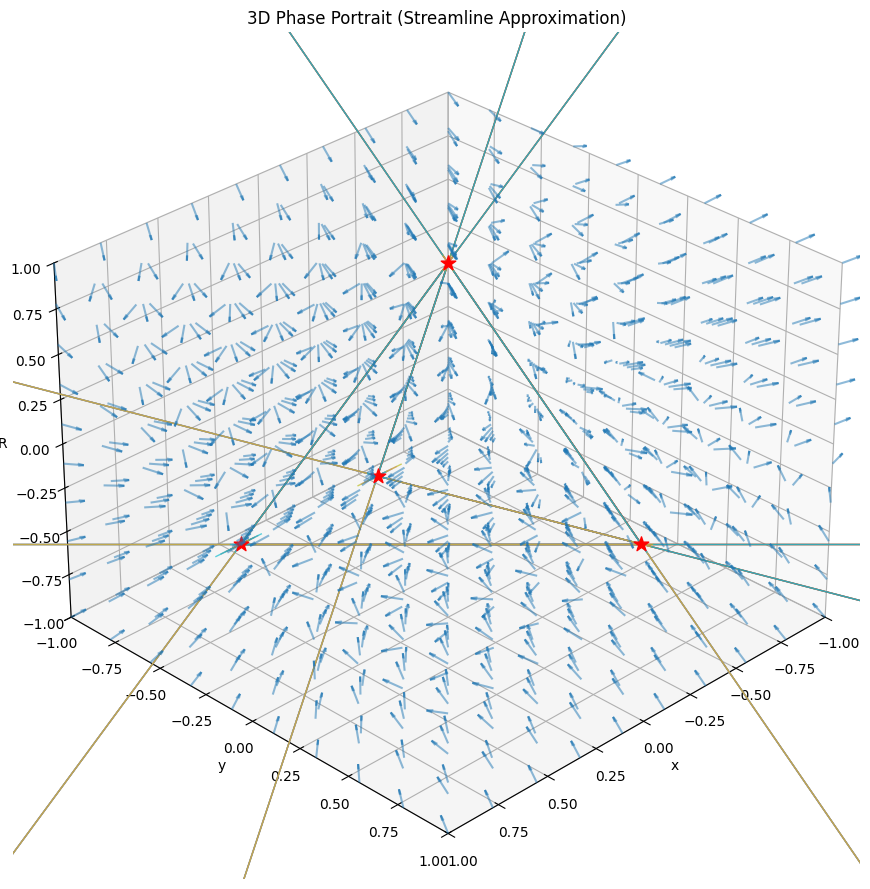

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp

w, q = -0.95, 0.05

def system(t, vars):
    x, y, R = vars

    dx = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - R) + 4*x*R
    dy = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - R) + 4*y*R
    dR = -4*R + 3*(1+w)*x*R + 3*y*R + 4*R**2

    return [dx, dy, dR]

simulationTime = np.linspace(0, -50, 2000)


def phase_plot_3D():

    fig = plt.figure(figsize=(11,11))
    ax = fig.add_subplot(111, projection='3d')

    ax.set_title("3D Phase Portrait (Streamline Approximation)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("R")

    xg = np.linspace(-1, 1, 10)
    yg = np.linspace(-1, 1, 10)
    Rg = np.linspace(-1, 1, 10)

    X, Y, Z = np.meshgrid(xg, yg, Rg)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    W = np.zeros_like(Z)

    for i in range(len(xg)):
        for j in range(len(xg)):
            for k in range(len(xg)):
                vec = system(0, [X[i,j,k], Y[i,j,k], Z[i,j,k]])
                U[i,j,k], V[i,j,k], W[i,j,k] = vec

    # normalize arrows (important!)
    mag = np.sqrt(U**2 + V**2 + W**2) + 1e-10
    U, V, W = U/mag, V/mag, W/mag

    ax.quiver(
        X, Y, Z,
        U, V, W,
        length=0.08,
        normalize=True,
        alpha=0.5
    )




    x_FP, y_FP, R_FP = sp.symbols('x y R', real=True)

    f = 3*(1+w)*(x_FP**2 - x_FP) + 3*x_FP*y_FP + q*(1 - 2*y_FP - R_FP) + 4*x_FP*R_FP
    g = 3*(y_FP**2 - y_FP) + 3*x_FP*y_FP*(1+w) - q*(1 - 2*y_FP - R_FP) + 4*y_FP*R_FP
    h = -4*R_FP + 3*(1+w)*x_FP*R_FP + 3*y_FP*R_FP + 4*R_FP**2

    J = sp.Matrix([f, g, h]).jacobian([x_FP, y_FP, R_FP])

    solutions = sp.solve([f, g, h], [x_FP, y_FP, R_FP], dict=True)

    FP = []
    for sol in solutions:
        try:
            x_val = float(sol[x_FP])
            y_val = float(sol[y_FP])
            R_val = float(sol[R_FP])

            if x_val + y_val + R_val <= 1.0 + 1e-6:
                FP.append([x_val, y_val, R_val])
        except:
            pass

    print("Fixed points:", FP)

    def classify(eigvals):
        real = np.real(eigvals)
        if np.all(real < 0):
            return "Attractor"
        elif np.all(real > 0):
            return "Repeller"
        else:
            return "Saddle"

    for fp in FP:

        x_c, y_c, R_c = fp

        J_num = np.array(J.subs({x_FP: x_c, y_FP: y_c, R_FP: R_c}), dtype=float)
        eigvals, eigvecs = np.linalg.eig(J_num)

        stability = classify(eigvals)

        print(f"FP {fp} → {stability}, eig={eigvals}")

        ax.scatter(x_c, y_c, R_c, color='red', s=120, marker='*')

 
        delta = 0.02

        for i in range(3):
            v = np.real(eigvecs[:, i])
            v = v / np.linalg.norm(v)

            for pm in [-1, 1]:

                # multiple offsets → dense "flow"
                for scale in np.linspace(0.5, 2.0, 5):

                    x_start = np.array([x_c, y_c, R_c]) + pm * delta * scale * v

                    # forward + backward integration
                    for t_span in [(0, -10), (0, 10)]:

                        sol = solve_ivp(
                            system,
                            t_span,
                            x_start,
                            t_eval=np.linspace(t_span[0], t_span[1], 300),
                            rtol=1e-6,
                            atol=1e-6
                        )

                        ax.plot(
                            sol.y[0],
                            sol.y[1],
                            sol.y[2],
                            linewidth=1,
                            alpha=0.7
                        )

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    ax.view_init(elev=30, azim=45)
    plt.show()

phase_plot_3D()


## Plot of xyz 
#### with R=1-x-y-z to compare evolution of matter to both affine dark energy componants

Fixed points: [[0.0, 0.0, 0.0], [0.01723616731230882, 0.9827638326876912, 0.0], [0.3448275862068966, -0.017241379310344827, 0.6724137931034483], [1.0178515519859368, -0.01785155198593679, 0.0]]
FP [0.0, 0.0, 0.0] → Repeller, eig=[3.90087692 1.04912308 4.        ]
FP [0.01723616731230882, 0.9827638326876912, 0.0] → Saddle, eig=[ 2.85175385 -1.04912308  2.95087692]
FP [0.3448275862068966, -0.017241379310344827, 0.6724137931034483] → Attractor, eig=[-0.09912308 -4.         -2.95087692]
FP [1.0178515519859368, -0.01785155198593679, 0.0] → Saddle, eig=[-3.90087692 -2.85175385  0.09912308]


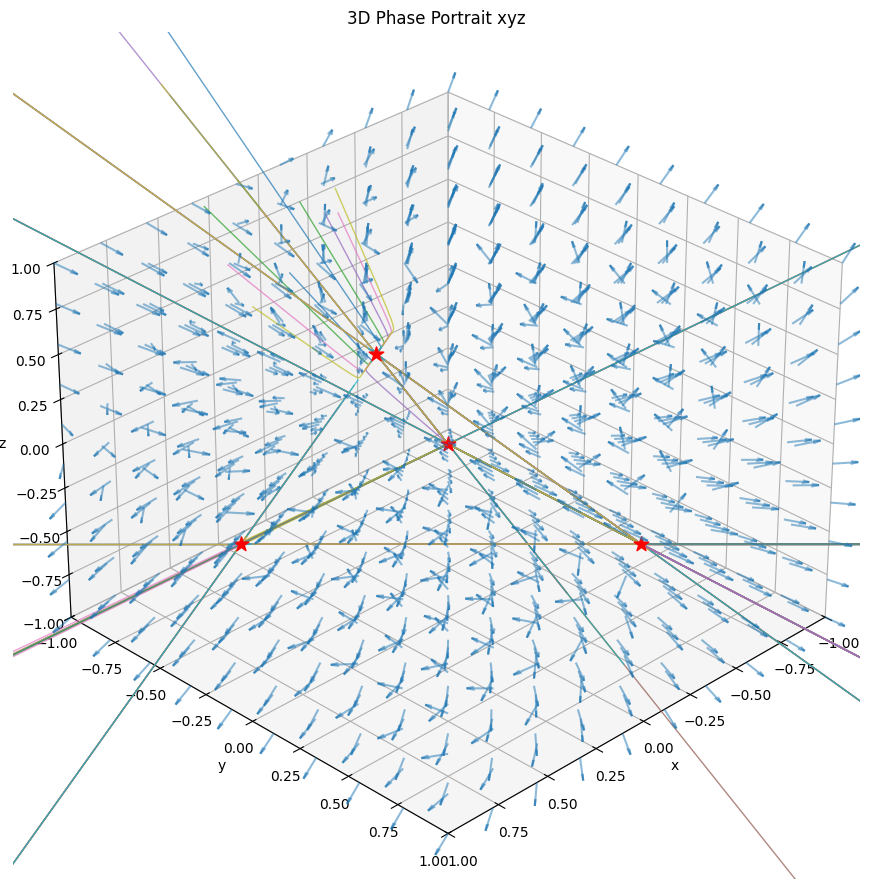

In [11]:
w, q = -0.95, 0.05

def system(t, vars):
    x, y, z = vars

    dx = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - (1-x-y-z)) + 4*x*(1-x-y-z)
    dy = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - (1-x-y-z)) + 4*y*(1-x-y-z)
    dz= 3*z*x*(1+w) +3*y*z+4*z*(1-x-y-z)
    #dR = -4*R + 3*(1+w)*x*R + 3*y*R + 4*R**2

    return [dx, dy, dz]

simulationTime = np.linspace(0, -50, 2000)


def phase_plot_3D():

    fig = plt.figure(figsize=(11,11))
    ax = fig.add_subplot(111, projection='3d')

    ax.set_title("3D Phase Portrait xyz")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    xg = np.linspace(-1, 1, 10)
    yg = np.linspace(-1, 1, 10)
    Rg = np.linspace(-1, 1, 10)

    X, Y, Z = np.meshgrid(xg, yg, Rg)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    W = np.zeros_like(Z)

    for i in range(len(xg)):
        for j in range(len(xg)):
            for k in range(len(xg)):
                vec = system(0, [X[i,j,k], Y[i,j,k], Z[i,j,k]])
                U[i,j,k], V[i,j,k], W[i,j,k] = vec

    # normalize arrows (important!)
    mag = np.sqrt(U**2 + V**2 + W**2) + 1e-10
    U, V, W = U/mag, V/mag, W/mag

    ax.quiver(
        X, Y, Z,
        U, V, W,
        length=0.1,
        normalize=True,
        alpha=0.5
    )




    x_FP, y_FP, z_FP = sp.symbols('x y z', real=True)

    f = 3*(1+w)*(x_FP**2 - x_FP) + 3*x_FP*y_FP + q*(1 - 2*y_FP - (1-x_FP-y_FP-z_FP)) + 4*x_FP*(1-x_FP-y_FP-z_FP)
    g = 3*(y_FP**2 - y_FP) + 3*x_FP*y_FP*(1+w) - q*(1 - 2*y_FP - (1-x_FP-y_FP-z_FP)) + 4*y_FP*(1-x_FP-y_FP-z_FP)
    h = 3*z_FP*x_FP*(1+w) +3*y_FP*z_FP+4*z_FP*(1-x_FP-y_FP-z_FP)

    J = sp.Matrix([f, g, h]).jacobian([x_FP, y_FP, z_FP])

    solutions = sp.solve([f, g, h], [x_FP, y_FP, z_FP], dict=True)

    FP = []
    for sol in solutions:
        try:
            x_val = float(sol[x_FP])
            y_val = float(sol[y_FP])
            z_val = float(sol[z_FP])

            if x_val + y_val + z_val <= 1.2 + 1e-6:
                FP.append([x_val, y_val, z_val])
        except:
            pass

    print("Fixed points:", FP)

    def classify(eigvals):
        real = np.real(eigvals)
        if np.all(real < 0):
            return "Attractor"
        elif np.all(real > 0):
            return "Repeller"
        else:
            return "Saddle"

    for fp in FP:

        x_c, y_c, z_c = fp

        J_num = np.array(J.subs({x_FP: x_c, y_FP: y_c, z_FP: z_c}), dtype=float)
        eigvals, eigvecs = np.linalg.eig(J_num)

        stability = classify(eigvals)

        print(f"FP {fp} → {stability}, eig={eigvals}")

        ax.scatter(x_c, y_c, z_c, color='red', s=120, marker='*')

 
        delta = 0.02

        for i in range(3):
            v = np.real(eigvecs[:, i])
            v = v / np.linalg.norm(v)

            for pm in [-1, 1]:

                # multiple offsets → dense "flow"
                for scale in np.linspace(0.5, 2.0, 5):

                    x_start = np.array([x_c, y_c, z_c]) + pm * delta * scale * v

                    # forward + backward integration
                    for t_span in [(0, -50), (0, 50)]:

                        sol = solve_ivp(
                            system,
                            t_span,
                            x_start,
                            t_eval=np.linspace(t_span[0], t_span[1], 300),
                            rtol=1e-6,
                            atol=1e-6
                        )

                        ax.plot(
                            sol.y[0],
                            sol.y[1],
                            sol.y[2],
                            linewidth=1,
                            alpha=0.7
                        )

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    ax.view_init(elev=30, azim=45)
    plt.show()

phase_plot_3D()


FP: (0.000, 0.000, 0.000)
Eigenvalues: [3.90087692 1.04912308 4.        ]
Stability: Repeller 

FP: (0.017, 0.983, 0.000)
Eigenvalues: [ 2.85175385 -1.04912308  2.95087692]
Stability: Saddle 



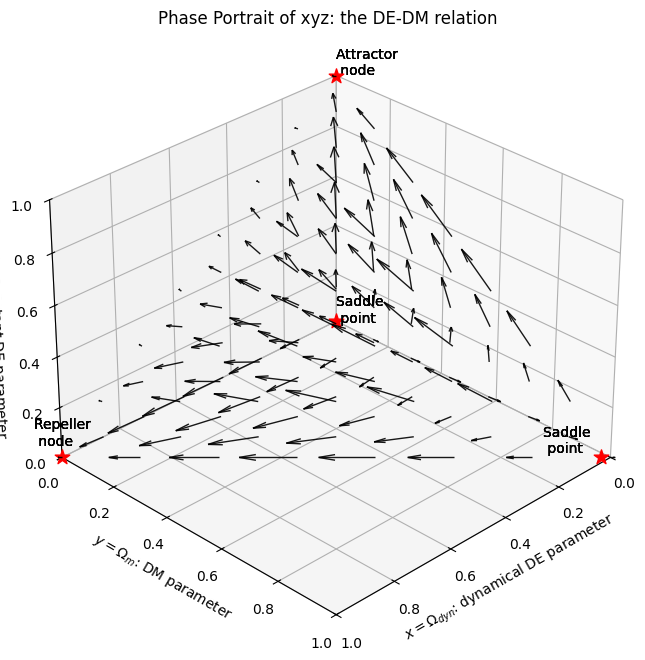

[[0.0, 0.0, 0.0], [0.01723616731230882, 0.9827638326876912, 0.0], (0, 0, 1), (1, 0, 0)]


In [50]:
w, q = -0.95, 0.05

def system(t, vars):
    x, y, z = vars
    R=1-x-y-z
    dx = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - R) + 4*x*R
    dy = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - R) + 4*y*R
    dz= 3*z*x*(1+w) +3*y*z+ 4*z*R
    #dR = -4*R + 3*(1+w)*x*R + 3*y*R + 4*R**2

    return [dx, dy, dz]

simulationTime = np.linspace(0, -50, 2000)
initialState =[0,0.3,0.7]

def phase_plot_3D():
    sol = solve_ivp(system, [0,-50], initialState , t_eval=simulationTime,rtol=1e-6, atol=1e-6)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
     #large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
    x = sol.y[0]
    y = sol.y[1]
    z=sol.y[2]

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    grid_points = 8   # LOWER = cleaner (Mathematica style)

    xg = np.linspace(0, 1, grid_points)
    yg = np.linspace(0, 1, grid_points)
    zg = np.linspace(0, 1, grid_points)

    X, Y, Z = np.meshgrid(xg, yg, zg)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    W = np.zeros_like(Z)

    for i in range(grid_points):
        for j in range(grid_points):
            for k in range(grid_points):
                xx, yy, zz = X[i, j, k], Y[i, j, k], Z[i, j, k]

                # Only physical region
                if xx + yy + zz > 1:
                    U[i,j,k] = np.nan
                    V[i,j,k] = np.nan
                    W[i,j,k] = np.nan
                    continue

                dx, dy, dz = system(0, [xx, yy, zz])

                U[i,j,k] = dx
                V[i,j,k] = dy
                W[i,j,k] = dz

    ax.quiver(X, Y, Z, U, V, W,
    length=0.15,          # uniform scaling
    normalize=False,      # IMPORTANT: keeps magnitude info
    color='black',linewidth=1.0,alpha=0.9)


    x_FP, y_FP, z_FP = sp.symbols('x y z', real=True)

    f = 3*(1+w)*(x_FP**2 - x_FP) + 3*x_FP*y_FP + q*(1 - 2*y_FP - (1-x_FP-y_FP-z_FP)) + 4*x_FP*(1-x_FP-y_FP-z_FP)
    g = 3*(y_FP**2 - y_FP) + 3*x_FP*y_FP*(1+w) - q*(1 - 2*y_FP - (1-x_FP-y_FP-z_FP)) + 4*y_FP*(1-x_FP-y_FP-z_FP)
    h = 3*z_FP*x_FP*(1+w) +3*y_FP*z_FP+4*z_FP*(1-x_FP-y_FP-z_FP)

    J = sp.Matrix([f, g, h]).jacobian([x_FP, y_FP, z_FP])

    solutions = sp.solve([f, g, h], [x_FP, y_FP, z_FP], dict=True)

    FP = []

    def classify(eigvals):
        real = np.real(eigvals)
        if np.all(real < 0):
            return "Attractor"
        elif np.all(real > 0):
            return "Repeller"
        else:
            return "Saddle"
    
    for sol in solutions:
        try:
            x_val = float(sol[x_FP])
            y_val = float(sol[y_FP])
            z_val = float(sol[z_FP])

            if x_val < 0 or y_val < 0 or z_val < 0:
                continue
            if x_val + y_val + z_val > 1 + 1e-6:
                continue
            
            J_num = np.array(J.subs(sol), dtype=float)
            eigvals = np.linalg.eigvals(J_num)

            print(f"FP: ({x_val:.3f}, {y_val:.3f}, {z_val:.3f})")
            print("Eigenvalues:", eigvals)
            print("Stability:", classify(eigvals) ,'\n' )

            FP.append([x_val, y_val, z_val])

        except:
            pass

    #print("Fixed points:", FP)
    Extra_FP = [(0,0,1),(1,0,0)]
    #x -> -0.0082713, y -> 0.016129, z -> 0.992142}, {x -> 0, y -> 0, 
    #z -> 0}, {x -> 0.0172362, y -> 0.982764, z -> 0.}, {x -> 1.01785, 
    #y -> -0.0178516, z -> 0.}}
    FP=FP+Extra_FP

    for fp in FP:

        x_c, y_c, z_c = fp
        delta=0.05
        #J_num = np.array(J.subs({x_FP: x_c, y_FP: y_c, z_FP: z_c}), dtype=float)
        #eigvals, eigvecs = np.linalg.eig(J_num)

        #stability = classify(eigvals)

        #print(f"FP {fp}, stability: {stability}, eig={eigvals}")

        ax.scatter(x_c, y_c, z_c, color='red', s=120, marker='*')
        ax.text(0+3*delta,1-2*delta,0+delta,'Saddle \n point')
        ax.text(0+delta,0+delta,0+delta,'Saddle \n point')
        ax.text(1+delta,0-delta,0+delta,'Repeller \n node')
        ax.text(0+delta,0+delta,1+delta,'Attractor \n node')

    ax.set_xlabel(r'$x=\Omega_{dyn}$: dynamical DE parameter')
    ax.set_ylabel(r'$y=\Omega_{m}$: DM parameter')
    ax.set_zlabel(r'$z=\Omega_{\Lambda}$: constant DE parameter')
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_zlim([0,1])
    ax.view_init(elev=30, azim=45)
    ax.set_title(r'Phase Portrait of xyz: the DE-DM relation')
    plt.show()
    print(FP)

phase_plot_3D()




--- Fixed Points ---

FP: (0.000, 0.000, 0.000)
Eigenvalues: [3.90087692 1.04912308 4.        ]
Stability: Repeller
Regime: Radiation 

FP: (0.017, 0.983, 0.000)
Eigenvalues: [ 2.85175385 -1.04912308  2.95087692]
Stability: Saddle
Regime: Mixed 



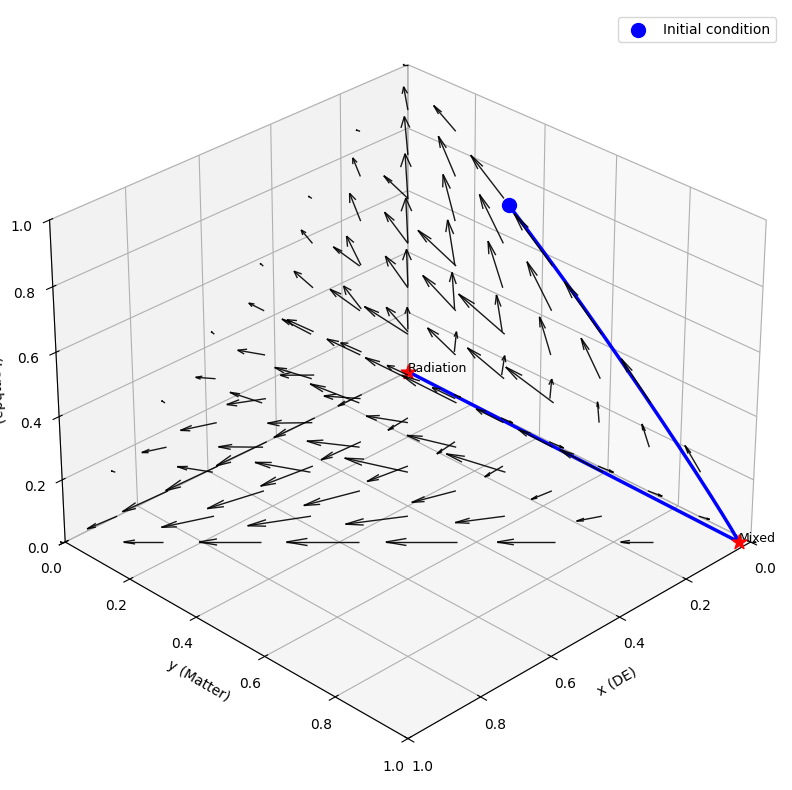

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Parameters
# -----------------------------
w, q = -0.95, 0.05

# -----------------------------
# System definition
# -----------------------------
def system(t, vars):
    x, y, z = vars
    R = 1 - x - y - z

    dx = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - R) + 4*x*R
    dy = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - R) + 4*y*R
    dz = 3*z*x*(1+w) + 3*y*z + 4*z*R

    return [dx, dy, dz]

# -----------------------------
# Integration (backwards time)
# -----------------------------
simulationTime = np.linspace(0, -50, 2000)
initialState = [0.0, 0.3, 0.7]

sol = solve_ivp(
    system,
    [0, -50],
    initialState,
    t_eval=simulationTime,
    rtol=1e-8,
    atol=1e-8
)

x_traj, y_traj, z_traj = sol.y

# -----------------------------
# Create vector field grid
# -----------------------------
grid_points = 8   # LOWER = cleaner (Mathematica style)

xg = np.linspace(0, 1, grid_points)
yg = np.linspace(0, 1, grid_points)
zg = np.linspace(0, 1, grid_points)

X, Y, Z = np.meshgrid(xg, yg, zg)

U = np.zeros_like(X)
V = np.zeros_like(Y)
W = np.zeros_like(Z)

for i in range(grid_points):
    for j in range(grid_points):
        for k in range(grid_points):
            xx, yy, zz = X[i, j, k], Y[i, j, k], Z[i, j, k]

            # Only physical region
            if xx + yy + zz > 1:
                U[i,j,k] = np.nan
                V[i,j,k] = np.nan
                W[i,j,k] = np.nan
                continue

            dx, dy, dz = system(0, [xx, yy, zz])

            U[i,j,k] = dx
            V[i,j,k] = dy
            W[i,j,k] = dz

# -----------------------------
# SymPy fixed points
# -----------------------------
x_s, y_s, z_s = sp.symbols('x y z', real=True)

R_s = 1 - x_s - y_s - z_s

f = 3*(1+w)*(x_s**2 - x_s) + 3*x_s*y_s + q*(1 - 2*y_s - R_s) + 4*x_s*R_s
g = 3*(y_s**2 - y_s) + 3*x_s*y_s*(1+w) - q*(1 - 2*y_s - R_s) + 4*y_s*R_s
h = 3*z_s*x_s*(1+w) + 3*y_s*z_s + 4*z_s*R_s

J = sp.Matrix([f, g, h]).jacobian([x_s, y_s, z_s])

solutions = sp.solve([f, g, h], [x_s, y_s, z_s], dict=True)

def classify(eigvals):
    real = np.real(eigvals)
    if np.all(real < 0):
        return "Attractor"
    elif np.all(real > 0):
        return "Repeller"
    else:
        return "Saddle"

def cosmology_label(x, y, z):
    if np.isclose(x,0,atol=1e-2) and np.isclose(y,0,atol=1e-2) and np.isclose(z,0,atol=1e-2):
        return "Radiation"
    if np.isclose(y,1,atol=1e-2):
        return "Matter domination"
    if np.isclose(x,1,atol=1e-2):
        return "Dynamical DE"
    if np.isclose(z,1,atol=1e-2):
        return "Λ domination"
    return "Mixed"

FP = []

print("\n--- Fixed Points ---\n")

for sol_fp in solutions:
    try:
        xv = float(sol_fp[x_s])
        yv = float(sol_fp[y_s])
        zv = float(sol_fp[z_s])

        if xv < 0 or yv < 0 or zv < 0:
            continue
        if xv + yv + zv > 1 + 1e-6:
            continue

        J_num = np.array(J.subs(sol_fp), dtype=float)
        eigvals = np.linalg.eigvals(J_num)

        stability = classify(eigvals)
        regime = cosmology_label(xv, yv, zv)

        print(f"FP: ({xv:.3f}, {yv:.3f}, {zv:.3f})")
        print("Eigenvalues:", eigvals)
        print("Stability:", stability)
        print("Regime:", regime, "\n")

        FP.append((xv, yv, zv, regime))

    except:
        pass

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# VECTOR FIELD (Mathematica-like)
ax.quiver(
    X, Y, Z,
    U, V, W,
    length=0.15,          # uniform scaling
    normalize=False,      # IMPORTANT: keeps magnitude info
    color='black',
    linewidth=1.0,
    alpha=0.9
)

# TRAJECTORY
ax.plot(
    x_traj, y_traj, z_traj,
    color='blue',
    linewidth=2.5
)

# INITIAL CONDITION
ax.scatter(
    initialState[0], initialState[1], initialState[2],
    color='blue',
    s=100,
    label='Initial condition'
)

# FIXED POINTS
for (xv, yv, zv, regime) in FP:
    ax.scatter(xv, yv, zv, color='red', s=120, marker='*')
    ax.text(xv, yv, zv, regime, fontsize=9)

# AXES
ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_zlim([0,1])

ax.set_xlabel('x (DE)')
ax.set_ylabel('y (Matter)')
ax.set_zlabel('z (Lambda)')

ax.view_init(elev=30, azim=45)

plt.legend()
plt.tight_layout()
plt.show()


=== FIXED POINT ANALYSIS ===

FP 1: {x: -0.00827129859387924, y: 0.0161290322580645, z: 0.992142266335815}
Regime: Lambda-like DE domination (z-field)
Eigenvalues: [-5.90087692315992, -3.04912307684008, -4.00000000000000]
Stability: Stable
------------------------------------------------------------
FP 2: {x: 0.0, y: 0.0, z: 0.0}
Regime: Radiation domination
Eigenvalues: [-1.90087692315992, 0.950876923159920, 4.00000000000000]
Stability: Unstable/Saddle
------------------------------------------------------------
FP 3: {x: 0.0172361673123088, y: 0.982763832687691, z: 0.0}
Regime: Mixed scaling regime
Eigenvalues: [-2.85175384631984, -0.950876923159920, 3.04912307684008]
Stability: Unstable/Saddle
------------------------------------------------------------
FP 4: {x: 1.01785155198594, y: -0.0178515519859368, z: 0.0}
Regime: Mixed scaling regime
Eigenvalues: [1.90087692315992, 2.85175384631984, 5.90087692315992]
Stability: Unstable/Saddle
------------------------------------------------

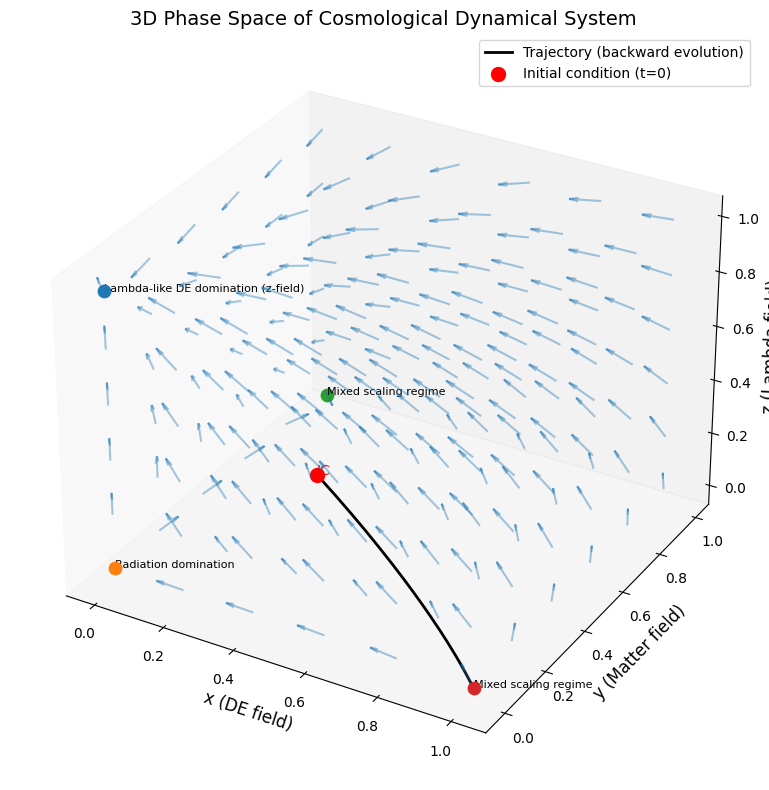

In [14]:
import numpy as np
import sympy as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# =========================
# Parameters
# =========================
w = 0.95
q = -0.05

# =========================
# Dynamical system
# =========================
x, y, z = sp.symbols('x y z', real=True)

R = 1 - x - y - z

dx = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - R) + 4*x*R
dy = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - R) + 4*y*R
dz = 3*z*x*(1+w) + 3*y*z + 4*z*R

f = sp.Matrix([dx, dy, dz])
vars_ = sp.Matrix([x, y, z])

# =========================
# Fixed points (symbolic)
# =========================
fps = sp.solve([dx, dy, dz], [x, y, z], dict=True)

# =========================
# Jacobian
# =========================
J = f.jacobian(vars_)

def classify(fp):
    xv, yv, zv = fp[x], fp[y], fp[z]
    if abs(xv) < 1e-3 and abs(yv) < 1e-3 and abs(zv) < 1e-3:
        return "Radiation domination"
    if abs(yv - 1) < 1e-2:
        return "Matter domination (y-field)"
    if abs(xv - 1) < 1e-2:
        return "Dark Energy domination (x-field)"
    if abs(zv - 1) < 1e-2:
        return "Lambda-like DE domination (z-field)"
    return "Mixed scaling regime"

print("\n=== FIXED POINT ANALYSIS ===\n")

eig_data = []

for i, fp in enumerate(fps):
    try:
        J_fp = J.subs(fp).evalf()
        eigvals = J_fp.eigenvals()

        eig_list = list(eigvals.keys())
        stable = all(sp.re(ev) < 0 for ev in eig_list)

        print(f"FP {i+1}: {fp}")
        print("Regime:", classify(fp))
        print("Eigenvalues:", eig_list)
        print("Stability:", "Stable" if stable else "Unstable/Saddle")
        print("-"*60)

        eig_data.append((fp, eig_list, stable))

    except Exception as e:
        print(f"FP {i+1} failed:", e)

# =========================
# Convert system for numerics
# =========================
def system(t, state):
    x, y, z = state
    R = 1 - x - y - z

    dxdt = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - R) + 4*x*R
    dydt = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - R) + 4*y*R
    dzdt = 3*z*x*(1+w) + 3*y*z + 4*z*R

    return [dxdt, dydt, dzdt]

# =========================
# Initial conditions (given constraint)
# x + z = 0.7, y ~ 0.3
# choose a representative point
# =========================
x0 = 0.4
y0 = 0.3
z0 = 0.3

y0 = np.clip(y0, 0, 1)

y_init = [x0, y0, z0]

# =========================
# Backward integration: 0 -> -50
# =========================
t_span = (0, -50)
t_eval = np.linspace(0, -50, 2000)

sol = solve_ivp(system, t_span, y_init, t_eval=t_eval, rtol=1e-9, atol=1e-9)

X, Y, Z = sol.y

# =========================
# Phase field (vector arrows)
# =========================
grid_n = 6
xs = np.linspace(0, 1, grid_n)
ys = np.linspace(0, 1, grid_n)
zs = np.linspace(0, 1, grid_n)

Xg, Yg, Zg = np.meshgrid(xs, ys, zs)

U = np.zeros_like(Xg)
V = np.zeros_like(Yg)
W = np.zeros_like(Zg)

for i in range(grid_n):
    for j in range(grid_n):
        for k in range(grid_n):
            xx, yy, zz = Xg[i,j,k], Yg[i,j,k], Zg[i,j,k]
            Rv = 1 - xx - yy - zz

            U[i,j,k] = 3*(1+w)*(xx**2 - xx) + 3*xx*yy + q*(1 - 2*yy - Rv) + 4*xx*Rv
            V[i,j,k] = 3*(yy**2 - yy) + 3*xx*yy*(1+w) - q*(1 - 2*yy - Rv) + 4*yy*Rv
            W[i,j,k] = 3*zz*xx*(1+w) + 3*yy*zz + 4*zz*Rv

# =========================
# Plot (Mathematica-like style)
# =========================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Trajectory
ax.plot(X, Y, Z, color='black', linewidth=2, label='Trajectory (backward evolution)')

# Direction field
ax.quiver(Xg, Yg, Zg, U, V, W, length=0.08, normalize=True, alpha=0.4)

# Fixed points
for fp, eigs, st in eig_data:
    xv, yv, zv = float(fp[x]), float(fp[y]), float(fp[z])
    ax.scatter(xv, yv, zv, s=80, marker='o')
    ax.text(xv, yv, zv, classify(fp), fontsize=8)

# Initial condition
ax.scatter(x0, y0, z0, color='red', s=100, label='Initial condition (t=0)')
ax.text(x0, y0, z0, "IC", color='red')

# Styling (Mathematica-like)
ax.set_xlabel("x (DE field)", fontsize=12)
ax.set_ylabel("y (Matter field)", fontsize=12)
ax.set_zlabel("z (Lambda field)", fontsize=12)

ax.set_title("3D Phase Space of Cosmological Dynamical System", fontsize=14)

ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


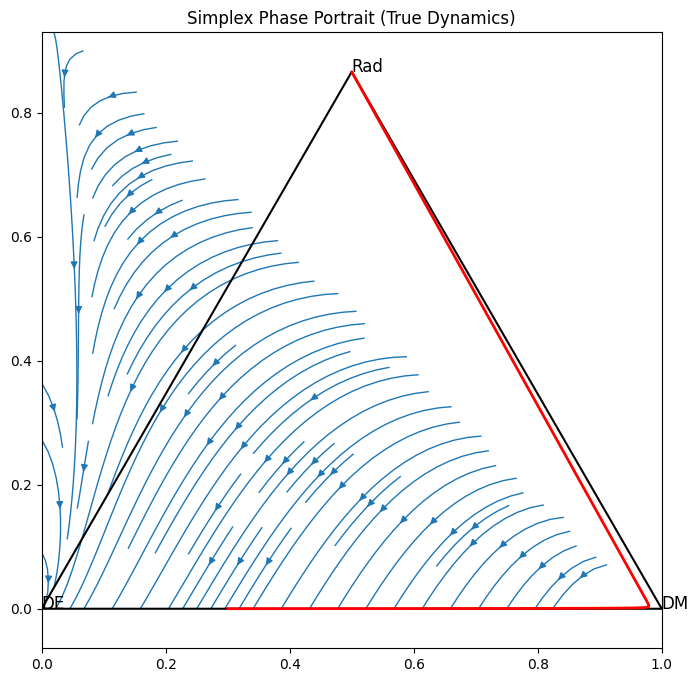

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -----------------------------
# PARAMETERS
# -----------------------------
w, q = -0.95, 0.05

# -----------------------------
# SYSTEM (same physics)
# -----------------------------
def system(N, vars):
    x, y, R = vars

    dx = 3*(1+w)*(x**2-x) + 3*x*y + q*(1-2*y-R) + 4*x*R
    dy = 3*(y**2-y) + 3*x*y*(1+w) - q*(1-2*y-R) + 4*y*R
    dR = -4*R + 3*(1+w)*x*R + 3*y*R + 4*R**2

    return [dx, dy, dR]

# -----------------------------
# SIMPLEX PROJECTION
# -----------------------------
def project(x, y, R):
    X = y + 0.5 * R
    Y = (np.sqrt(3)/2) * R
    return X, Y

# -----------------------------
# GRID IN SIMPLEX
# -----------------------------
n = 40
x_vals = np.linspace(0, 1, n)
y_vals = np.linspace(0, 1, n)

X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

U = np.zeros_like(X_grid)
V = np.zeros_like(Y_grid)

for i in range(n):
    for j in range(n):
        x = X_grid[i,j]
        y = Y_grid[i,j]
        R = 1 - x - y

        if R < 0:
            U[i,j] = np.nan
            V[i,j] = np.nan
            continue

        dx, dy, dR = system(0, [x, y, R])

        # project derivatives
        dX = dy + 0.5*dR
        dY = (np.sqrt(3)/2)*dR

        U[i,j] = dX
        V[i,j] = dY

# -----------------------------
# PLOT STREAMLINES
# -----------------------------
plt.figure(figsize=(8,8))

plt.streamplot(
    X_grid, Y_grid,
    U, V,
    density=1.5,
    linewidth=1
)

# -----------------------------
# PLOT TRIANGLE BOUNDARY
# -----------------------------
triangle = np.array([
    project(1,0,0),
    project(0,1,0),
    project(0,0,1),
    project(1,0,0)
])

plt.plot(triangle[:,0], triangle[:,1], 'k')

# label corners
plt.text(*project(1,0,0), "DE", fontsize=12)
plt.text(*project(0,1,0), "DM", fontsize=12)
plt.text(*project(0,0,1), "Rad", fontsize=12)

# -----------------------------
# TRAJECTORY
# -----------------------------
t = np.linspace(0, -50, 2000)
sol = solve_ivp(system, [0,-50], [0.68,0.3,1e-4], t_eval=t)

Xp, Yp = project(sol.y[0], sol.y[1], sol.y[2])
plt.plot(Xp, Yp, 'r', lw=2)

plt.title("Simplex Phase Portrait (True Dynamics)")
plt.axis('equal')
plt.xlim(0,1)
plt.ylim(0,np.sqrt(3)/2)

plt.show()

ValueError: The rows of 'x' must be equal

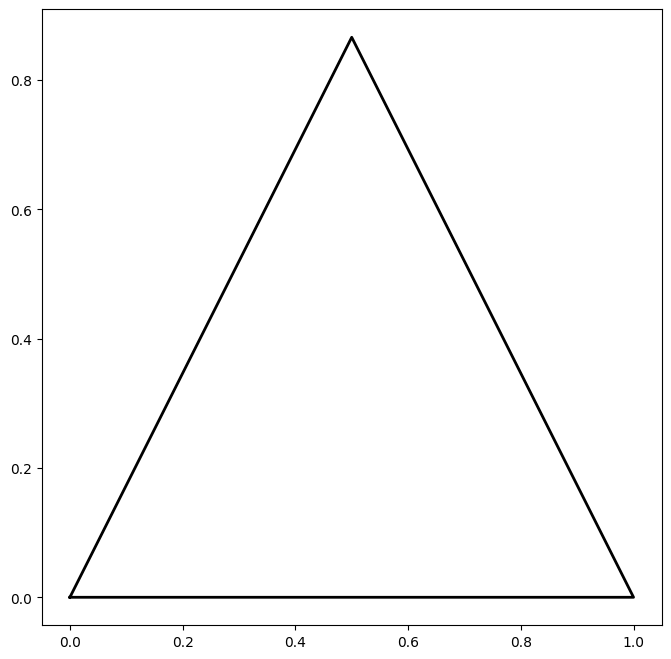

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------
w, q = -0.95, 0.05

# -----------------------------
# SYSTEM
# -----------------------------
def system(t, vars):
    x, y, R = vars
    dx = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - R) + 4*x*R
    dy = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - R) + 4*y*R
    dR = -4*R + 3*(1+w)*x*R + 3*y*R + 4*R**2
    return np.array([dx, dy, dR])

# -----------------------------
# SIMPLEX GEOMETRY
# -----------------------------
A = np.array([0.0, 0.0])                     # x vertex
B = np.array([1.0, 0.0])                     # y vertex
C = np.array([0.5, np.sqrt(3)/2])            # R vertex

def bary_to_cart(a,b,c):
    return a*A + b*B + c*C

def project_vector(x,y,R,dx,dy,dR):
    s = x+y+R
    ds = dx+dy+dR
    a,b,c = x/s, y/s, R/s

    da = dx/s - a*ds/s
    db = dy/s - b*ds/s
    dc = dR/s - c*ds/s

    dX = da*A[0] + db*B[0] + dc*C[0]
    dY = da*A[1] + db*B[1] + dc*C[1]
    return dX, dY

# -----------------------------
# RECTANGULAR GRID IN (a,b)
# -----------------------------
N = 200
a_vals = np.linspace(0,1,N)
b_vals = np.linspace(0,1,N)

Agrid, Bgrid = np.meshgrid(a_vals, b_vals)
Cgrid = 1 - Agrid - Bgrid

mask = Cgrid >= 0   # inside simplex

# -----------------------------
# PROJECT GRID TO SIMPLEX
# -----------------------------
X = np.zeros_like(Agrid)
Y = np.zeros_like(Bgrid)

for i in range(N):
    for j in range(N):
        if mask[i,j]:
            X[i,j], Y[i,j] = bary_to_cart(Agrid[i,j], Bgrid[i,j], Cgrid[i,j])
        else:
            X[i,j], Y[i,j] = np.nan, np.nan

# -----------------------------
# COMPUTE PROJECTED VECTOR FIELD
# -----------------------------
U = np.zeros_like(X)
V = np.zeros_like(Y)

for i in range(N):
    for j in range(N):
        if mask[i,j]:
            a = Agrid[i,j]
            b = Bgrid[i,j]
            c = Cgrid[i,j]

            x,y,R = a,b,c
            dx,dy,dR = system(0,[x,y,R])
            U[i,j], V[i,j] = project_vector(x,y,R,dx,dy,dR)
        else:
            U[i,j], V[i,j] = np.nan, np.nan

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(8,8))

# simplex boundary
ax.plot([A[0],B[0],C[0],A[0]],
        [A[1],B[1],C[1],A[1]], 'k-', lw=2)

# streamplot
ax.streamplot(X, Y, U, V, density=1.2, color='blue', linewidth=1)

# -----------------------------
# FIXED POINTS
# -----------------------------
FPs = [
    (1,0,0),
    (0,1,0),
    (0,0,1),
    (0.3,0,0)
]

for x,y,R in FPs:
    s = x+y+R
    a,b,c = x/s, y/s, R/s
    Xp,Yp = bary_to_cart(a,b,c)
    ax.scatter(Xp,Yp, color='red', s=120, marker='*')

ax.set_aspect('equal')
ax.set_xlim(-0.1,1.1)
ax.set_ylim(-0.1,np.sqrt(3)/2+0.1)
ax.set_title("Simplex Phase Portrait (x,y,R)")

plt.show()


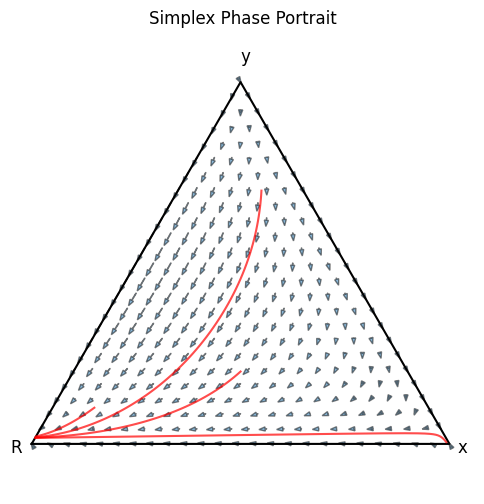

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# PARAMETERS
w = -0.5
q = -0.05

# -----------------------------
# SYSTEM (reduced: x,y only)
# -----------------------------
def system(t, vars):
    x, y = vars
    R = 1 - x - y
    
    dx = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y)
    dy = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y)
    
    return [dx, dy]

# -----------------------------
# SIMPLEX MAPPING
# -----------------------------
def to_triangle(x, y):
    X = x + 0.5*y
    Y = (np.sqrt(3)/2)*y
    return X, Y

# -----------------------------
# PLOT TRIANGLE
# -----------------------------
def draw_simplex():
    triangle = np.array([
        [0, 0],                 # (0,0,1)
        [1, 0],                 # (1,0,0)
        [0.5, np.sqrt(3)/2],    # (0,1,0)
        [0, 0]
    ])
    plt.plot(triangle[:,0], triangle[:,1], 'k')

# -----------------------------
# TRAJECTORY PLOTTING
# -----------------------------
def plot_trajectory(ic):
    sol = solve_ivp(system, (0, 20), ic, t_eval=np.linspace(0,20,800))
    
    x = sol.y[0]
    y = sol.y[1]
    
    # keep only valid simplex region
    valid = (x >= -1e-6) & (y >= -1e-6) & (x + y <= 1 + 1e-6)
    x, y = x[valid], y[valid]
    
    X, Y = to_triangle(x, y)
    
    plt.plot(X, Y, 'r', alpha=0.7)

# -----------------------------
# VECTOR FIELD (projected)
# -----------------------------
def plot_vector_field(n=25):
    xs = np.linspace(0, 1, n)
    ys = np.linspace(0, 1, n)
    
    for x in xs:
        for y in ys:
            if x >= 0 and y >= 0 and x + y <= 1:
                
                dx, dy = system(0, [x, y])
                
                X, Y = to_triangle(x, y)
                
                # small step forward
                X2, Y2 = to_triangle(x + 0.05*dx, y + 0.05*dy)
                
                plt.arrow(X, Y, X2-X, Y2-Y,
                          head_width=0.01,
                          alpha=0.5,
                          length_includes_head=True)

# -----------------------------
# MAIN PLOT
# -----------------------------
plt.figure(figsize=(6,6))

draw_simplex()
plot_vector_field()

# sample initial conditions
ICs = [
    (0.99, 0.005),
    (0.2, 0.7),
    (0.4, 0.2),
    (0.1, 0.1)
]

for ic in ICs:
    plot_trajectory(ic)

# labels
plt.text(1.02, -0.02, "x", fontsize=12)
plt.text(-0.05, -0.02, "R", fontsize=12)
plt.text(0.5, np.sqrt(3)/2 + 0.05, "y", fontsize=12)

plt.title("Simplex Phase Portrait")
plt.axis('equal')
plt.axis('off')

plt.show()

### 2D plot of x vs y but using $Q=qH\frac{\rho_X^2}{\rho_x+\rho_m}$

In [ ]:
w,q =-0.95,0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]



simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
# generate the state-space trajectory
ICs=[0.00001,0.99]

def traj(IC): # change to forward time -50,50 for expanding and 50,-50 reverse time for contracting
    sol = solve_ivp(system, t_span=(simulationTime[0],simulationTime[-1]), y0=ICs,t_eval=simulationTime, method='RK45', rtol=1e-6, atol=1e-6)
    return sol

def plot_traj(sol):
    x = sol.y[0]
    y = sol.y[1]

    #plt.plot(x,y ,color='r',linestyle='--',alpha = 0.7,label="Trajectory")
    x0,y0 = x[-2],y[-2]
    X_diff=x[-1] -x[-2]
    Y_diff=y[-1] -y[-2]
    plt.arrow(x0, y0, X_diff, Y_diff, head_width=0.03, head_length=0.05, length_includes_head=True, color='r',linestyle='--')


#plotting phase portrait 
def phase_plot():

  FP = find_fixed_points()
  

  
  print("Detected fixed points:",FP)


  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-1.5,1.5,500)
  x1 = np.linspace(-1.5,1.5,500)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
                if abs(X0[i,j]) >= 1.5 or abs(X1[i,j]) >= 1.5:
                  dX0[i,j] = 0
                  dX1[i,j] = 0
                else:
                  dx,dy = system(0,[X0[i,j], X1[i,j]])
                  dX0[i,j] = dx
                  dX1[i,j] = dy

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, density=1.9, linewidth=1)
  #plt.plot(x_vals, y_vals, 'r', lw=2, label='Trajectory')
  #plt.plot(x_vals[0], y_vals[0], 'ro', label='Initial condition')

    #   forcing the separatrices for w=-0.5 and q=-0.05, remove otherwise
    #1.54834,-1.50333
  a=np.linspace(0,1,100)
  b=[(-i)+1  for i in a]

  d=np.linspace(0.344828,1,100)
  c=np.zeros_like(d)
  plt.plot(a,b,'r--')
  plt.plot(d,c-0.015,'r--')




  initial_conditions = [(0.99, 0.01), (0.1, 0.99)]
  for dx0,dy0 in initial_conditions:
        sol = traj([dx0,dy0])
        plot_traj(sol)


  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

  for fp in FP:
    x_c, y_c = fp
    plt.plot(x_c, y_c, 'k*', markersize=12)
    delta = 1e-6
    # DO NOT skip the saddle at (1,0)
    if (abs(x_c) >= 1 or abs(y_c) >= 1) and not np.allclose([x_c, y_c], [1,0], atol=1e-3):
      
      stability = "saddle"
      point_type = "Boundary"

      starts = [
                [x_c-delta,y_c],
                [x_c,y_c-delta],
                [x_c-delta,y_c-delta],
                [x_c-delta,y_c+delta]
            ]

      for start in starts:

                  start = np.clip(start,-0.999,0.999)

                  sol = solve_ivp(system,(-10, 0),start,t_eval=simulationTime)
                  #plt.plot(sol.y[0], sol.y[1], 'r--')

      continue






    
    # creating a numerical jacobian because the sympy function doesnt work when functions blow up to infinities at +-1

    eps=1e-6
    fx1 = system(0,[x_c+eps,y_c])
    fx2 = system(0,[x_c-eps,y_c])

    fy1 = system(0,[x_c,y_c+eps])
    fy2 = system(0,[x_c,y_c-eps])

    J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

    eigvals,eigvecs = np.linalg.eig(J)

    stability,point_type = classify_FP(eigvals)




    print(f'Fixed points ({x_c:},{y_c:})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plt.plot(x_c, y_c, 'k*', markersize=12,label='Fixed Points')
    plt.text(x_c+0.04, y_c-0.1, f"{point_type}\n{stability}", fontsize=10)
    plt.text(1-0.04, 0-0.1, f"Saddle \n Point", fontsize=10)
    
    #plt.plot(1,0,'k*', markersize=12,label='Saddle Point')
    #plt.text(1-0.04, 0-0.1, f"Saddle Point", fontsize=10)

  #plt.plot(1,0,'k*', markersize=12,label='Saddle Point')
  plt.xlabel(rf"$x$",fontsize=24)
  plt.ylabel(rf"$y$",fontsize=24)
  plt.title(rf"Phase portrait of x vs y for $w={w:.3f}$ and $q={q}$",fontsize=18)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.3,1.1)


  #plt.legend()
  
  plt.show()





def find_fixed_points():
    guesses = np.linspace(-1.5,1.5,40)
    FP = []
    for g1 in guesses:
        for g2 in guesses:
            sol = root(lambda v: system(0,[v[0],v[1]]), [g1,g2])
            if sol.success:
                x, y = sol.x

                if abs(x) <= 1.5 and abs(y) <= 1.5:
                    dx,dy = system(0,[x,y])

                    if abs(dx) < 1e-6 and abs(dy) < 1e-6:
                        pt = np.round([x,y],6)

                        if not any(np.allclose(pt,p,atol=1e-4) for p in FP):
                            FP.append(pt)

    return FP


phase_plot()

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018
